# CS 6830 - Data Science in Practice 
**Project 2 - Crime and Housing in Austin, Texas (2015)** 

Mary Dufie Afrane and Zach Maughan

## Importing libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

pd.set_option('display.max_columns', None)

## Loading the data

In [2]:
crime_df = pd.read_csv('crime-housing-austin-2015.csv')
zips_df = pd.read_csv('AustinZipCodes.csv')
print('Crime data:', crime_df.shape)
print('Zip code data:', zips_df.shape)

Crime data: (38573, 43)
Zip code data: (43, 7)


In [3]:
crime_df.head()

,Key,Council_District,Highest_Offense_Desc,Highest_NIBRS_UCR_Offense_Description,Report_Date,Location,Clearance_Status,Clearance_Date,District,Zip_Code_Crime,Census_Tract,X_Coordinate,Y_Coordinate,Zip_Code_Housing,Populationbelowpovertylevel,Medianhouseholdincome,Non-WhiteNon-HispanicorLatino,HispanicorLatinoofanyrace,Populationwithdisability,Unemployment,Largehouseholds(5+members),Homesaffordabletopeopleearninglessthan$50000,Rentalsaffordabletopeopleearninglessthan$25000,Rent-restrictedunits,HousingChoiceVoucherholders,Medianrent,Medianhomevalue,Percentageofrentalunitsinpoorcondition,Percentchangeinnumberofhousingunits2000-2012,Ownerunitsaffordabletoaverageretail/serviceworker,Rentalunitsaffordabletoaverageretail/serviceworker,Rentalunitsaffordabletoaverageartist,Ownerunitsaffordabletoaverageartist,Rentalunitsaffordabletoaverageteacher,Ownerunitsaffordabletoaverageteacher,Rentalunitsaffordabletoaveragetechworker,Ownerunitsaffordabletoaveragetechworker,Changeinpercentageofpopulationbelowpoverty2000-2012,Changeinmedianrent2000-2012,Changeinmedianhomevalue2000-2012,Percentageofhomeswithin1/4-mioftransitstop,Averagemonthlytransportationcost,Percentageofhousingandtransportationcoststhatistransportation-related
0,201510782,4.0,AGG ROBBERY/DEADLY WEAPON,Robbery,1-Jan-15,9001 N IH 35 SVRD NB,N,28-Jan-15,E,78753.0,18.13,3130483.0,10102366.0,78753.0,26%,$39593,20%,60%,10%,9%,16%,78%,14%,17%,4%,$826,$134900,0.7%,19%,8%,11%,40%,24%,89%,75%,100%,98%,128%,26%,40%,59%,$708,44%
1,201511231,4.0,ROBBERY BY ASSAULT,Robbery,1-Jan-15,919 E KOENIG LN SVRD EB,N,13-Jan-15,I,78751.0,21.05,3124730.0,10090296.0,78751.0,26%,$38624,11%,14%,6%,9%,2%,11%,13%,1%,0%,$865,$292200,0.4%,7%,0%,9%,38%,2%,68%,10%,97%,42%,23%,38%,97%,98%,$550,40%
2,201511736,1.0,BURGLARY OF RESIDENCE,Burglary,1-Jan-15,12151 N IH 35 SVRD NB,N,13-Jan-15,E,78753.0,18.35,3135985.0,10117220.0,78753.0,26%,$39593,20%,60%,10%,9%,16%,78%,14%,17%,4%,$826,$134900,0.7%,19%,8%,11%,40%,24%,89%,75%,100%,98%,128%,26%,40%,59%,$708,44%
3,201511433,4.0,BURGLARY OF RESIDENCE,Burglary,1-Jan-15,1044 NORWOOD PARK BLVD,N,5-Jan-15,I,78753.0,18.13,3129896.0,10096032.0,78753.0,26%,$39593,20%,60%,10%,9%,16%,78%,14%,17%,4%,$826,$134900,0.7%,19%,8%,11%,40%,24%,89%,75%,100%,98%,128%,26%,40%,59%,$708,44%
4,201511936,2.0,BURGLARY OF RESIDENCE,Burglary,1-Jan-15,2413 BITTER CREEK DR,N,7-Jan-15,F,78744.0,24.27,3110455.0,10039340.0,78744.0,26%,$41056,9%,77%,8%,9%,23%,93%,7%,24%,8%,$946,$108100,0.7%,35%,13%,6%,22%,33%,81%,87%,100%,100%,89%,26%,44%,63%,$708,40%


In [4]:
crime_df.columns

Index(['Key', 'Council_District', 'Highest_Offense_Desc',
       'Highest_NIBRS_UCR_Offense_Description', 'Report_Date', 'Location',
       'Clearance_Status', 'Clearance_Date', 'District', 'Zip_Code_Crime',
       'Census_Tract', 'X_Coordinate', 'Y_Coordinate', 'Zip_Code_Housing',
       'Populationbelowpovertylevel', 'Medianhouseholdincome',
       'Non-WhiteNon-HispanicorLatino', 'HispanicorLatinoofanyrace',
       'Populationwithdisability', 'Unemployment',
       'Largehouseholds(5+members)',
       'Homesaffordabletopeopleearninglessthan$50000',
       'Rentalsaffordabletopeopleearninglessthan$25000',
       'Rent-restrictedunits', 'HousingChoiceVoucherholders', 'Medianrent',
       'Medianhomevalue', 'Percentageofrentalunitsinpoorcondition',
       'Percentchangeinnumberofhousingunits2000-2012',
       'Ownerunitsaffordabletoaverageretail/serviceworker',
       'Rentalunitsaffordabletoaverageretail/serviceworker',
       'Rentalunitsaffordabletoaverageartist',
       'Ownerunits

In [5]:
crime_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 38573 entries, 0 to 38572
Data columns (total 43 columns):
 #   Column                                                                 Non-Null Count  Dtype  
---  ------                                                                 --------------  -----  
 0   Key                                                                    38573 non-null  int64  
 1   Council_District                                                       38401 non-null  float64
 2   Highest_Offense_Desc                                                   38573 non-null  str    
 3   Highest_NIBRS_UCR_Offense_Description                                  38573 non-null  str    
 4   Report_Date                                                            38573 non-null  str    
 5   Location                                                               38092 non-null  str    
 6   Clearance_Status                                                       36649 non-null  str    
 7

In [6]:
zips_df.head()

,#,Zip Code,Location,City,Population,People / Sq. Mile,National Rank
0,1,78705,"30.293474, -97.738268","Austin, Texas","26,825","11,008.66",#519
1,2,78751,"30.310819, -97.722821","Austin, Texas","14,005","5,822.28","#1,374"
2,3,78752,"30.331288, -97.704660","Austin, Texas","18,030","5,435.92","#1,528"
3,4,78741,"30.229845, -97.715136","Austin, Texas","40,661","5,346.47","#1,562"
4,5,78723,"30.305341, -97.683344","Austin, Texas","30,110","5,175.95","#1,640"


In [7]:
zips_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 43 entries, 0 to 42
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   #                  43 non-null     int64
 1   Zip Code           43 non-null     int64
 2   Location           43 non-null     str  
 3   City               43 non-null     str  
 4   Population         43 non-null     str  
 5   People / Sq. Mile  43 non-null     str  
 6   National Rank      43 non-null     str  
dtypes: int64(2), str(5)
memory usage: 2.5 KB


## Data Cleaning

Several columns are stored as text with `%` or `$` symbols, so we convert the ones we will use to numeric types. We also clean up the population column in the zip code file, which has commas in it.

In [8]:
# Clean population column in the zip code file
zips_clean = zips_df[['Zip Code', 'Population']].copy()
zips_clean['Population'] = zips_clean['Population'].str.replace(',', '').astype(int)
zips_clean = zips_clean.rename(columns={'Zip Code': 'ZipCode'})
zips_clean.head()

,ZipCode,Population
0,78705,26825
1,78751,14005
2,78752,18030
3,78741,40661
4,78723,30110


## Calculating crime rate per capita
So we group all crime records by ZIP code and counts how many crime records are in each ZIP code from `crime_df`. Then create a new column called ZipCode and convert the ZIP codes to integers so that the ZIP code format matches the ZIP codes in `zip_clean`. Then we create a new table`crime_rate_by_zip` that combines `crime_counts`  with `zips_clean` table using `ZipCode`

Then compute the crime rate using 
Crime rate per 1000 = (Number of crimes/Population)×1000

In [9]:
zips_clean['ZipCode'].nunique()

43

In [10]:
crime_df['Zip_Code_Housing'].nunique()

36

In [11]:
crime_counts = crime_df.groupby('Zip_Code_Housing').size().reset_index(name='CrimeCount')
crime_counts['ZipCode'] = crime_counts['Zip_Code_Housing'].astype(int)

crime_rate_by_zip = crime_counts.merge(zips_clean, on='ZipCode')
crime_rate_by_zip['CrimeRatePer1000'] = crime_rate_by_zip['CrimeCount'] / crime_rate_by_zip['Population'] * 1000

# number of ZIP codes that successfully had both crime data and population data  
print(f'Zip codes with crime rate calculated: {len(crime_rate_by_zip)}')

crime_rate_by_zip[['ZipCode', 'Population', 'CrimeCount', 'CrimeRatePer1000']].sort_values('CrimeRatePer1000', ascending=False)

Zip codes with crime rate calculated: 35


,ZipCode,Population,CrimeCount,CrimeRatePer1000
0,78701,3855,2103,545.525292
30,78754,5422,428,78.937661
29,78753,44210,3472,78.534268
1,78702,22534,1668,74.021479
19,78741,40661,2973,73.116746
8,78723,30110,2124,70.541348
27,78751,14005,927,66.190646
28,78752,18030,1178,65.335552
24,78748,25361,1536,60.565435
33,78758,42820,2563,59.855208


## Zip-level economic and housing attributes
Housing/demographic statistics repeat identically for every crime in a given zip code (we confirmed every zip code has exactly one unique value per housing column), so we collapse down to one row per zip code and clean the two percentage columns we need: unemployment rate (Analysis 1) and transit access (Analysis 2)

In [12]:
zip_attrs = crime_df.dropna(subset=['Zip_Code_Housing']).drop_duplicates(subset=['Zip_Code_Housing'])[['Zip_Code_Housing', 'Unemployment', 'Percentageofhomeswithin1/4-mioftransitstop']].copy()
zip_attrs['ZipCode'] = zip_attrs['Zip_Code_Housing'].astype(int)
zip_attrs['UnemploymentPct'] = zip_attrs['Unemployment'].str.replace('%', '', regex=False).astype(float)
zip_attrs['TransitAccessPct'] = zip_attrs['Percentageofhomeswithin1/4-mioftransitstop'].str.replace('%', '', regex=False).astype(float)

# Combine into one master zip-level table: economic/housing attributes + crime rate, all in one place
zip_stats = zip_attrs[['ZipCode', 'UnemploymentPct', 'TransitAccessPct']].merge(crime_rate_by_zip, on='ZipCode')
zip_stats.head()

,ZipCode,UnemploymentPct,TransitAccessPct,Zip_Code_Housing,CrimeCount,Population,CrimeRatePer1000
0,78753,9.0,59.0,78753.0,3472,44210,78.534268
1,78751,9.0,98.0,78751.0,927,14005,66.190646
2,78744,9.0,63.0,78744.0,1921,33706,56.992820
3,78741,9.0,80.0,78741.0,2973,40661,73.116746
4,78727,6.0,24.0,78727.0,539,22212,24.266162


### A note on zip 78701
I think ZIP code 78701 is an outlier because its crime rate is much higher than other areas. I checked and 78701 in Austin texas seems to be downtown area and since downtowns usually have many visitors and workers but relatively few residents, maybe we exclude it from any residential neighborhood analysis? 

# Analysis

## Does the unemployment rate relate to crime rate?
Do zip codes with higher unemployment also have higher crime rates?

### Filter to residential zip codes
We use the `zip_stats` table, excluding downtown Austin (zip 78701) 

In [13]:
unemployment_analysis = zip_stats[zip_stats['ZipCode'] != 78701]
print(f'Zip codes in analysis: {len(unemployment_analysis)}')
unemployment_analysis[['ZipCode', 'UnemploymentPct', 'CrimeRatePer1000']].head()

Zip codes in analysis: 34


,ZipCode,UnemploymentPct,CrimeRatePer1000
0,78753,9.0,78.534268
1,78751,9.0,66.190646
2,78744,9.0,56.992820
3,78741,9.0,73.116746
4,78727,6.0,24.266162


### Averages and standard deviations

In [14]:
print('Unemployment rate: mean = {:.3f}%, std = {:.3f}%'.format(
    unemployment_analysis['UnemploymentPct'].mean(), unemployment_analysis['UnemploymentPct'].std()))
print('Crime rate per 1,000: mean = {:.3f}, std = {:.3f}'.format(
    unemployment_analysis['CrimeRatePer1000'].mean(), unemployment_analysis['CrimeRatePer1000'].std()))

Unemployment rate: mean = 7.206%, std = 3.043%
Crime rate per 1,000: mean = 43.403, std = 21.726


### Scatterplot

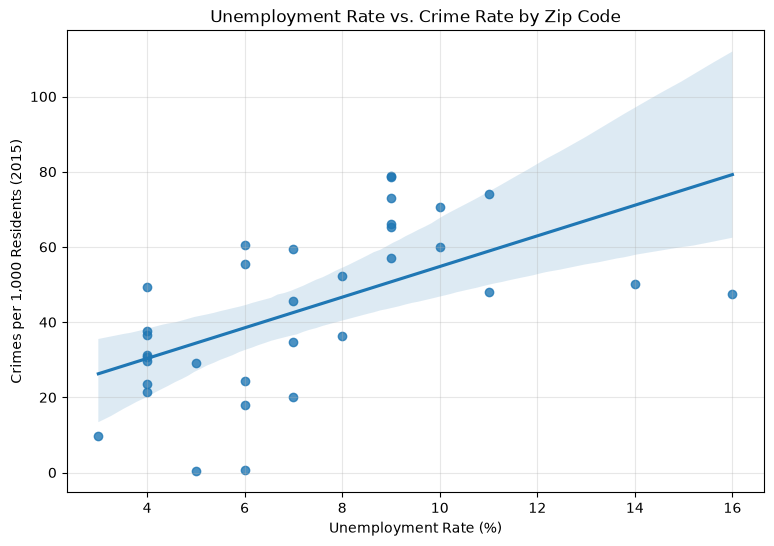

In [15]:
plt.figure(figsize=(9, 6))
sns.regplot(data=unemployment_analysis, x='UnemploymentPct', y='CrimeRatePer1000')
plt.title('Unemployment Rate vs. Crime Rate by Zip Code')
plt.xlabel('Unemployment Rate (%)')
plt.ylabel('Crimes per 1,000 Residents (2015)')
plt.grid(True, alpha=0.3)
plt.show()

### Pearson correlation

In [16]:
r, p_value = stats.pearsonr(unemployment_analysis['UnemploymentPct'], unemployment_analysis['CrimeRatePer1000'])
print(f'Pearson r = {r:.3f}')
print(f'p-value = {p_value:.6f}')
print(f'n = {len(unemployment_analysis)} zip codes')

Pearson r = 0.571
p-value = 0.000424
n = 34 zip codes


## Does transit access relate specifically to auto theft?
Do zip codes with more homes near a public transit stop see more car theft?

### Build auto theft counts per zip code, then combine with transit access
We need counts of one specific offense type (auto theft) rather than all crime, so we filter and count that separately here, then merge it with the transit access percentage from `zip_stats`, filling in 0 for any zip code with no recorded auto thefts. We calculate both a raw count and a per-capita rate so we can check whether the relationship holds either way.

In [17]:
auto_theft_counts = crime_df[crime_df['Highest_NIBRS_UCR_Offense_Description'] == 'Auto Theft'].groupby('Zip_Code_Crime').size().reset_index(name='AutoTheftCount')
auto_theft_counts['ZipCode'] = auto_theft_counts['Zip_Code_Crime'].astype('Int64').astype(int)

auto_theft_analysis = zip_stats[['ZipCode', 'TransitAccessPct', 'Population']].merge(
    auto_theft_counts[['ZipCode', 'AutoTheftCount']], on='ZipCode', how='left')
auto_theft_analysis['AutoTheftCount'] = auto_theft_analysis['AutoTheftCount'].fillna(0)
auto_theft_analysis['AutoTheftRatePer1000'] = auto_theft_analysis['AutoTheftCount'] / auto_theft_analysis['Population'] * 1000

print(f'Zip codes in analysis: {len(auto_theft_analysis)}')
auto_theft_analysis.sort_values('TransitAccessPct', ascending=False).head(8)

Zip codes in analysis: 35


,ZipCode,TransitAccessPct,Population,AutoTheftCount,AutoTheftRatePer1000
25,78705,100.0,26825,78.0,2.907735
1,78751,98.0,14005,51.0,3.641557
19,78722,98.0,6365,23.0,3.613511
12,78701,97.0,3855,72.0,18.677043
10,78702,96.0,22534,81.0,3.594568
17,78756,90.0,7128,17.0,2.384961
5,78721,87.0,10124,23.0,2.271829
13,78723,84.0,30110,94.0,3.121886


### Averages and standard deviations

In [18]:
for col, label in [('TransitAccessPct', 'Transit access (%)'), ('AutoTheftCount', 'Raw auto theft count'), ('AutoTheftRatePer1000', 'Auto theft rate per 1,000 residents')]:
    print(f'{label}: mean = {auto_theft_analysis[col].mean():.3f}, std = {auto_theft_analysis[col].std():.3f}')

Transit access (%): mean = 49.171, std = 35.529
Raw auto theft count: mean = 54.657, std = 53.950
Auto theft rate per 1,000 residents: mean = 2.738, std = 3.093


### Scatterplots

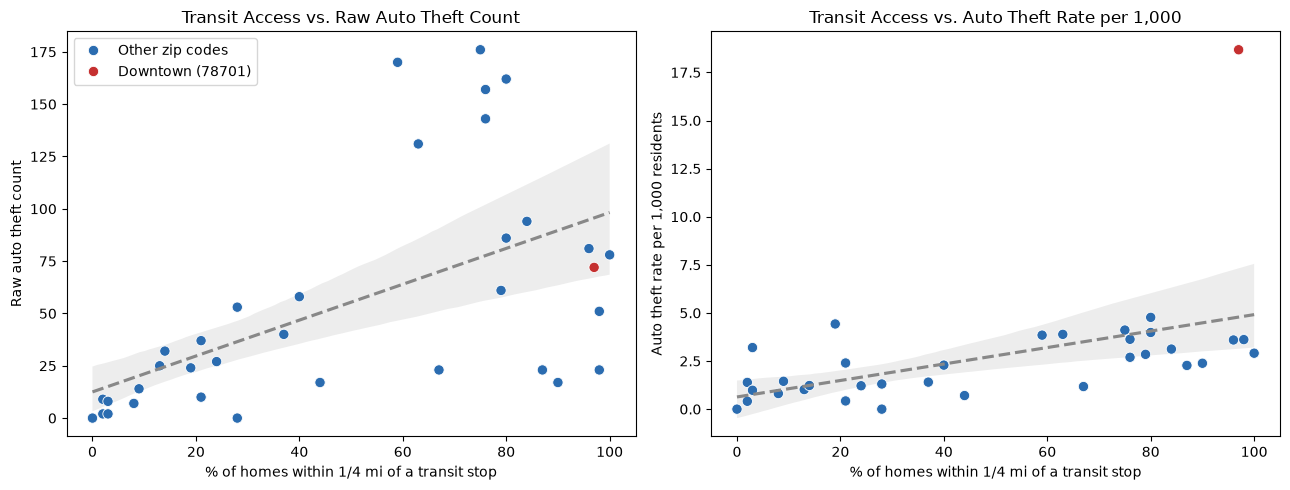

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
auto_theft_analysis['Zip Code Type'] = auto_theft_analysis['ZipCode'].map(
    lambda z: 'Downtown (78701)' if z == 78701 else 'Other zip codes')

for ax, ycol, ylabel in [
    (axes[0], 'AutoTheftCount', 'Raw auto theft count'),
    (axes[1], 'AutoTheftRatePer1000', 'Auto theft rate per 1,000 residents'),
]:
    sns.regplot(data=auto_theft_analysis, x='TransitAccessPct', y=ycol, ax=ax, scatter=False, ci=95,
                line_kws={'color': '#888888', 'linestyle': '--'})
    sns.scatterplot(data=auto_theft_analysis, x='TransitAccessPct', y=ycol, hue='Zip Code Type', ax=ax,
                     palette={'Other zip codes': '#2b6cb0', 'Downtown (78701)': '#c53030'}, s=55,
                     edgecolor='white', legend=(ax is axes[0]))
    ax.set_xlabel('% of homes within 1/4 mi of a transit stop')
    ax.set_ylabel(ylabel)

axes[0].set_title('Transit Access vs. Raw Auto Theft Count')
axes[0].legend(title=None, loc='upper left')
axes[1].set_title('Transit Access vs. Auto Theft Rate per 1,000')
plt.tight_layout()
plt.show()

### Pearson correlation

In [20]:
r_cnt, p_cnt = stats.pearsonr(auto_theft_analysis['TransitAccessPct'], auto_theft_analysis['AutoTheftCount'])
r_rate, p_rate = stats.pearsonr(auto_theft_analysis['TransitAccessPct'], auto_theft_analysis['AutoTheftRatePer1000'])
print(f'Transit access vs. raw auto theft count:  r = {r_cnt:.3f}, p = {p_cnt:.5f}')
print(f'Transit access vs. auto theft rate/1,000: r = {r_rate:.3f}, p = {p_rate:.5f}')

no_outlier = auto_theft_analysis[auto_theft_analysis['ZipCode'] != 78701]
r_cnt2, p_cnt2 = stats.pearsonr(no_outlier['TransitAccessPct'], no_outlier['AutoTheftCount'])
r_rate2, p_rate2 = stats.pearsonr(no_outlier['TransitAccessPct'], no_outlier['AutoTheftRatePer1000'])
print(f'(excluding 78701) raw count:  r = {r_cnt2:.3f}, p = {p_cnt2:.5f}')
print(f'(excluding 78701) rate/1,000: r = {r_rate2:.3f}, p = {p_rate2:.5f}')

Transit access vs. raw auto theft count:  r = 0.564, p = 0.00041
Transit access vs. auto theft rate/1,000: r = 0.492, p = 0.00271
(excluding 78701) raw count:  r = 0.568, p = 0.00046
(excluding 78701) rate/1,000: r = 0.654, p = 0.00003


### Mann-Whitney U test

In [21]:
median_transit = auto_theft_analysis['TransitAccessPct'].median()
high_transit = auto_theft_analysis[auto_theft_analysis['TransitAccessPct'] >= median_transit]['AutoTheftRatePer1000']
low_transit = auto_theft_analysis[auto_theft_analysis['TransitAccessPct'] < median_transit]['AutoTheftRatePer1000']

u_stat, p_value = stats.mannwhitneyu(high_transit, low_transit, alternative='two-sided')
print(f'High-transit mean auto theft rate: {high_transit.mean():.2f} per 1,000 (n={len(high_transit)})')
print(f'Low-transit mean auto theft rate:  {low_transit.mean():.2f} per 1,000 (n={len(low_transit)})')
print(f'Mann-Whitney U = {u_stat:.0f}, p-value = {p_value:.5f}')

High-transit mean auto theft rate: 3.99 per 1,000 (n=18)
Low-transit mean auto theft rate:  1.41 per 1,000 (n=17)
Mann-Whitney U = 260, p-value = 0.00044


## Does crime happen more on weekends than weekdays?
We want to know if there is a real, statistically meaningful difference between weekend and weekday crime levels

### Convert `Report_Date` to an actual date type, then count how many crimes were reported on each individual calendar day in 2015, and label each day as a weekday or weekend day.

In [22]:
crime_df['ReportDate'] = pd.to_datetime(crime_df['Report_Date'], format='%d-%b-%y')
crime_df['DayOfWeek'] = crime_df['ReportDate'].dt.day_name()

daily_counts = crime_df.groupby('ReportDate').size().reset_index(name='CrimeCount')
daily_counts['IsWeekend'] = daily_counts['ReportDate'].dt.dayofweek >= 5  # Saturday=5, Sunday=6
daily_counts.head()

,ReportDate,CrimeCount,IsWeekend
0,2015-01-01,82,False
1,2015-01-02,113,False
2,2015-01-03,93,True
3,2015-01-04,81,True
4,2015-01-05,125,False


### Split into weekday vs. weekend groups

In [23]:
weekend_counts = daily_counts[daily_counts['IsWeekend']]['CrimeCount']
weekday_counts = daily_counts[~daily_counts['IsWeekend']]['CrimeCount']

print(f'Weekend days in 2015: n = {len(weekend_counts)}')
print(f'Weekday days in 2015: n = {len(weekday_counts)}')

Weekend days in 2015: n = 104
Weekday days in 2015: n = 261


### Averages and standard deviations

In [24]:
print('Weekend: mean = {:.3f} crimes/day, std = {:.3f}'.format(weekend_counts.mean(), weekend_counts.std()))
print('Weekday: mean = {:.3f} crimes/day, std = {:.3f}'.format(weekday_counts.mean(), weekday_counts.std()))

Weekend: mean = 86.221 crimes/day, std = 13.030
Weekday: mean = 113.433 crimes/day, std = 16.393


###  Distribution

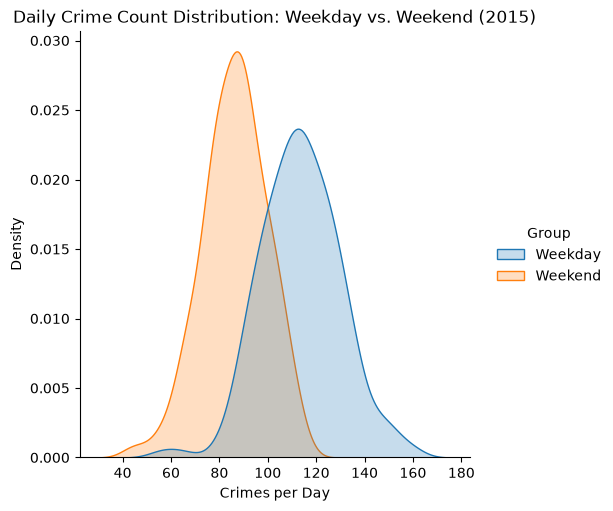

In [25]:
daycompare_df = daily_counts.copy()
daycompare_df['Group'] = daycompare_df['IsWeekend'].map({True: 'Weekend', False: 'Weekday'})

sns.displot(data=daycompare_df, x='CrimeCount', hue='Group', kind='kde', common_norm=False, fill=True)
plt.xlabel('Crimes per Day')
plt.title('Daily Crime Count Distribution: Weekday vs. Weekend (2015)')
plt.show()

### T-test

In [51]:
t_stat, p_value = stats.ttest_ind(weekday_counts, weekend_counts)
print(f't-statistic = {t_stat:.3f}')
print(f'p-value = {p_value:.6f}')

t-statistic = 15.127
p-value = 0.000000


## Does crime severity relate to whether a case gets cleared?
Are more severe crimes (murder, rape) more likely to get "cleared" i.e. closed by arrest or other means than less severe ones (auto theft, simple theft)?

### A note on the clearance_date column
The dataset includes a `Clearance_Date` column that, according to the assignment description, sometimes has a valid date even when `Clearance_Status` is `N` (not cleared) which shouldn't be possible if the column truly means "the date the crime was cleared." Because this ambiguity is never explained by the data source, we used only `Clearance_Status` (a clean, unambiguous C/O/N flag) for the analysis and did not use `Clearance_Date` at all, which avoids the issue entirely.

### Build the clearance and severity data
We need a binary "was this crime cleared" flag and a severity ranking for each offense type. There's no severity column in the raw data, so we build one using the FBI's official UCR Hierarchy Rule i.e. the same ranking the FBI itself uses to decide which offense "counts" when an incident involves more than one crime. In ascending order of seriousness: Auto Theft < Theft < Burglary < Aggravated Assault < Robbery < Rape < Murder.

We drop rows with a missing `Clearance_Status`, since we can't classify those crimes as cleared or not. Then we calculate the clearance rate for each of the 7 offense categories, sorted from least to most severe.

In [55]:
clearance_df = crime_df.dropna(subset=['Clearance_Status']).copy()
clearance_df['is_cleared'] = clearance_df['Clearance_Status'].isin(['C', 'O']).astype(int)

severity_map = {
    'Auto Theft': 1,
    'Theft': 2,
    'Burglary': 3,
    'Agg Assault': 4,
    'Robbery': 5,
    'Rape': 6,
    'Murder': 7,
}
clearance_df['severity'] = clearance_df['Highest_NIBRS_UCR_Offense_Description'].map(severity_map)

print(f'Rows dropped for missing clearance status: {len(crime_df) - len(clearance_df)}')
print(f'Rows remaining: {len(clearance_df)}')
print(f'Offense types that did not map to a severity score: {clearance_df["severity"].isna().sum()}')

cat_table = (
    clearance_df.groupby('Highest_NIBRS_UCR_Offense_Description')
    .agg(n=('is_cleared', 'size'), n_cleared=('is_cleared', 'sum'))
    .reset_index()
)
cat_table['clearance_rate_pct'] = cat_table['n_cleared'] / cat_table['n'] * 100
cat_table['severity'] = cat_table['Highest_NIBRS_UCR_Offense_Description'].map(severity_map)
cat_table = cat_table.sort_values('severity').reset_index(drop=True)

cat_table_display = cat_table.rename(columns={'Highest_NIBRS_UCR_Offense_Description': 'offense'})
cat_table_display['clearance_rate_pct'] = cat_table_display['clearance_rate_pct'].round(1)
cat_table_display

Rows dropped for missing clearance status: 1924
Rows remaining: 36649
Offense types that did not map to a severity score: 0


,offense,n,n_cleared,clearance_rate_pct,severity
0,Auto Theft,1988,362,18.2,1
1,Theft,26673,3611,13.5,2
2,Burglary,4852,543,11.2,3
3,Agg Assault,1839,1140,62.0,4
4,Robbery,829,276,33.3,5
5,Rape,450,238,52.9,6
6,Murder,18,17,94.4,7


### Averages and standard deviations

In [57]:
overall_rate = clearance_df['is_cleared'].mean() * 100
print(f'Overall clearance rate across all crimes: {overall_rate:.2f}%')
print()

sev_cleared = clearance_df.loc[clearance_df['is_cleared'] == 1, 'severity']
sev_not = clearance_df.loc[clearance_df['is_cleared'] == 0, 'severity']
print(f'Mean severity among CLEARED crimes:     {sev_cleared.mean():.2f} (std = {sev_cleared.std():.2f}, n = {len(sev_cleared)})')
print(f'Mean severity among NOT CLEARED crimes: {sev_not.mean():.2f} (std = {sev_not.std():.2f}, n = {len(sev_not)})')

Overall clearance rate across all crimes: 16.88%

Mean severity among CLEARED crimes:     2.70 (std = 1.22, n = 6187)
Mean severity among NOT CLEARED crimes: 2.22 (std = 0.72, n = 30462)


### Scatterplot
Each point is one of the 7 offense categories, sized by how many crimes of that type were reported.

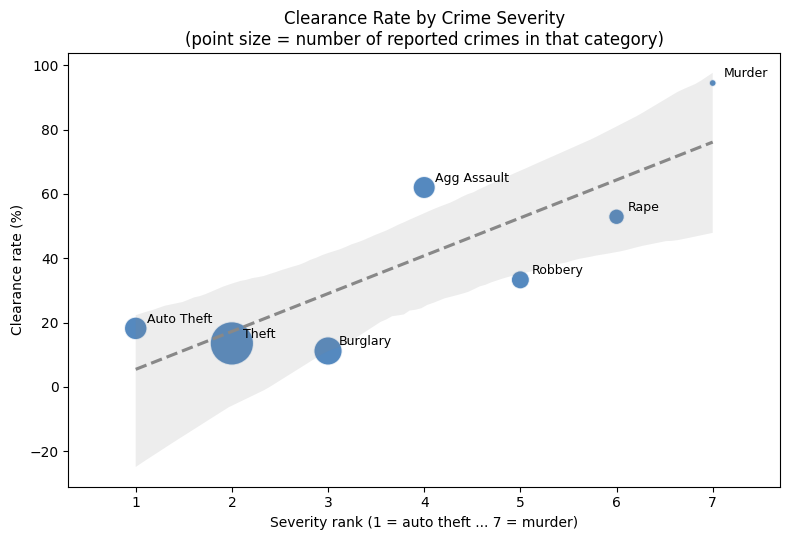

In [59]:
fig, ax = plt.subplots(figsize=(8, 5.5))
sizes = (cat_table['n'] ** 0.5 * 6).values

sns.regplot(data=cat_table, x='severity', y='clearance_rate_pct', ax=ax, ci=95,
            scatter_kws={'s': sizes, 'edgecolor': 'white', 'color': '#2b6cb0'},
            line_kws={'color': '#888888', 'linestyle': '--'})

for _, row in cat_table.iterrows():
    ax.annotate(row['Highest_NIBRS_UCR_Offense_Description'],
                (row['severity'], row['clearance_rate_pct']),
                textcoords='offset points', xytext=(8, 4), fontsize=9)

ax.set_xlabel('Severity rank (1 = auto theft ... 7 = murder)')
ax.set_ylabel('Clearance rate (%)')
ax.set_title('Clearance Rate by Crime Severity\n(point size = number of reported crimes in that category)')
ax.set_xlim(0.3, 7.7)
plt.tight_layout()
plt.show()

### Pearson correlation
We run this two ways since they answer slightly different questions:
- **Individual level:** every one of the ~36,600 crimes with a known clearance status gets its own row (severity vs. the binary cleared/not-cleared flag)
- **Category level:** just the 7 offense types, correlating severity rank against each category's overall clearance rate

We check both because if they agree, that's stronger evidence than either alone.

In [61]:
r_ind, p_ind = stats.pearsonr(clearance_df['severity'], clearance_df['is_cleared'])
r_agg, p_agg = stats.pearsonr(cat_table['severity'], cat_table['clearance_rate_pct'])

print(f'Individual-level Pearson r = {r_ind:.3f}, p = {p_ind:.6f}, n = {len(clearance_df)}')
print(f'Category-level   Pearson r = {r_agg:.3f}, p = {p_agg:.6f}, n = {len(cat_table)}')

Individual-level Pearson r = 0.214, p = 0.000000, n = 36649
Category-level   Pearson r = 0.828, p = 0.021505, n = 7
